---

VIX calibration

---

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
from rbergomi import RoughBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
import pandas as pd

sns.set_theme("talk")
mpl.rcParams["figure.figsize"] = (8, 6)
COLORS = ["blue", "green", "red", "orange"]
SEED = 1234

# 22 Nov 2017

In [68]:
# load market data
df = pd.read_csv("data/vix_smile_2017.csv", sep=";")
df = df.iloc[0:9]
tab_strike = 1e-2 * df.iloc[0][4:-2].to_numpy().astype(float)
tab_mat = np.arange(1, 9) / 12
tab_fut = 1e-2 * df["F"][1:].to_numpy().astype(float)
tab_impvol = np.zeros((8, 16))
for i in range(1, 9):
    tab_impvol[i - 1, :] = np.array(df.iloc[i][4:-2]) / 100

In [69]:
tab_fut

array([0.1148, 0.1288, 0.1383, 0.1458, 0.1518, 0.1568, 0.1613, 0.167 ])

In [70]:
H = 0.1

list_x0 = np.array(
    [
        np.log(0.014483720994143206),
        np.log(0.0213),
        np.log(0.02629),
        np.log(0.02927),
    ]
)
list_eta1 = np.array([1.89695265, 1.85768486, 1.746, 1.40721303]) / np.sqrt(2 * H)
list_eta2 = np.array([0.19704152, 0.15271809, 0.167, 0.12376835]) / np.sqrt(2 * H)
list_lbd = np.array([0.32418895, 0.49170964, 0.55, 0.6499])

In [130]:
EPS = 1e-3
N_QUAD = 40
ORDER = 0

impvol_approx = {}
fut_approx = {}


for i in range(len(list_x0)):
    params = {
        "s0": 1.0,
        "xi0": lambda u: np.ones_like(u) * np.exp(list_x0[i]),
        "rho": -0.7,
        "H": H,
        "eta": list_eta1[i],
    }
    rbergomi = RoughBergomi(**params)

    lbd = list_lbd[i]
    eta_2 = list_eta2[i]
    T = tab_mat[i]
    fut_approx[T] = rbergomi.price_vix_approx_mixed(
        T=T,
        K=0.0,
        lbd=lbd,
        eta_2=eta_2,
        order=ORDER,
        opt_payoff="fut",
        eps=EPS,
        n_quad=N_QUAD,
    )
    k = np.log(tab_strike / fut_approx[T])

    impvol_approx[T] = rbergomi.implied_vol_vix_approx_mixed(
        lbd=lbd,
        eta_2=eta_2,
        k=k,
        T=T,
        order=ORDER,
        eps=EPS,
        n_quad=N_QUAD,
    )

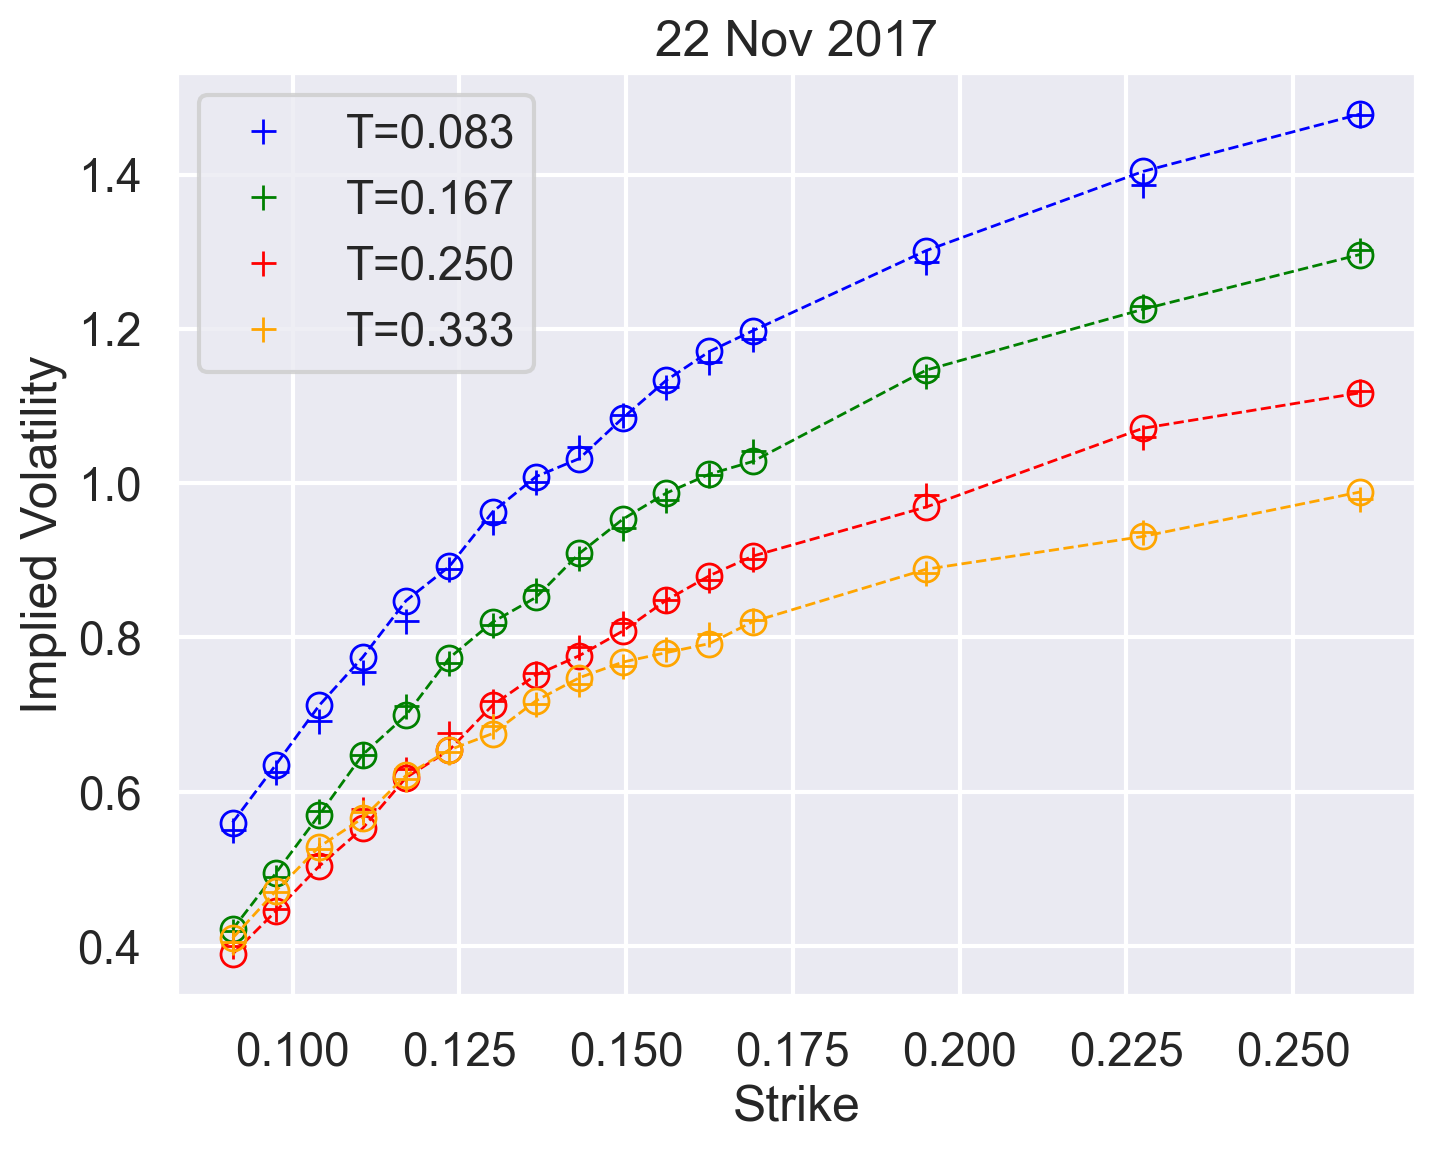

In [131]:
# plot vix smiles
fig, ax = plt.subplots()
for i in range(4):
    ax.plot(
        tab_strike,
        tab_impvol[i, :],
        "+",
        color=COLORS[i],
        label=f"T={tab_mat[i]:.3f}",
    )
    ax.plot(
        tab_strike,
        impvol_approx[tab_mat[i]],
        "--o",
        color=COLORS[i],
        fillstyle="none",
        linewidth=1.0,
    )
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.set_title("22 Nov 2017")
ax.legend()
plt.show()

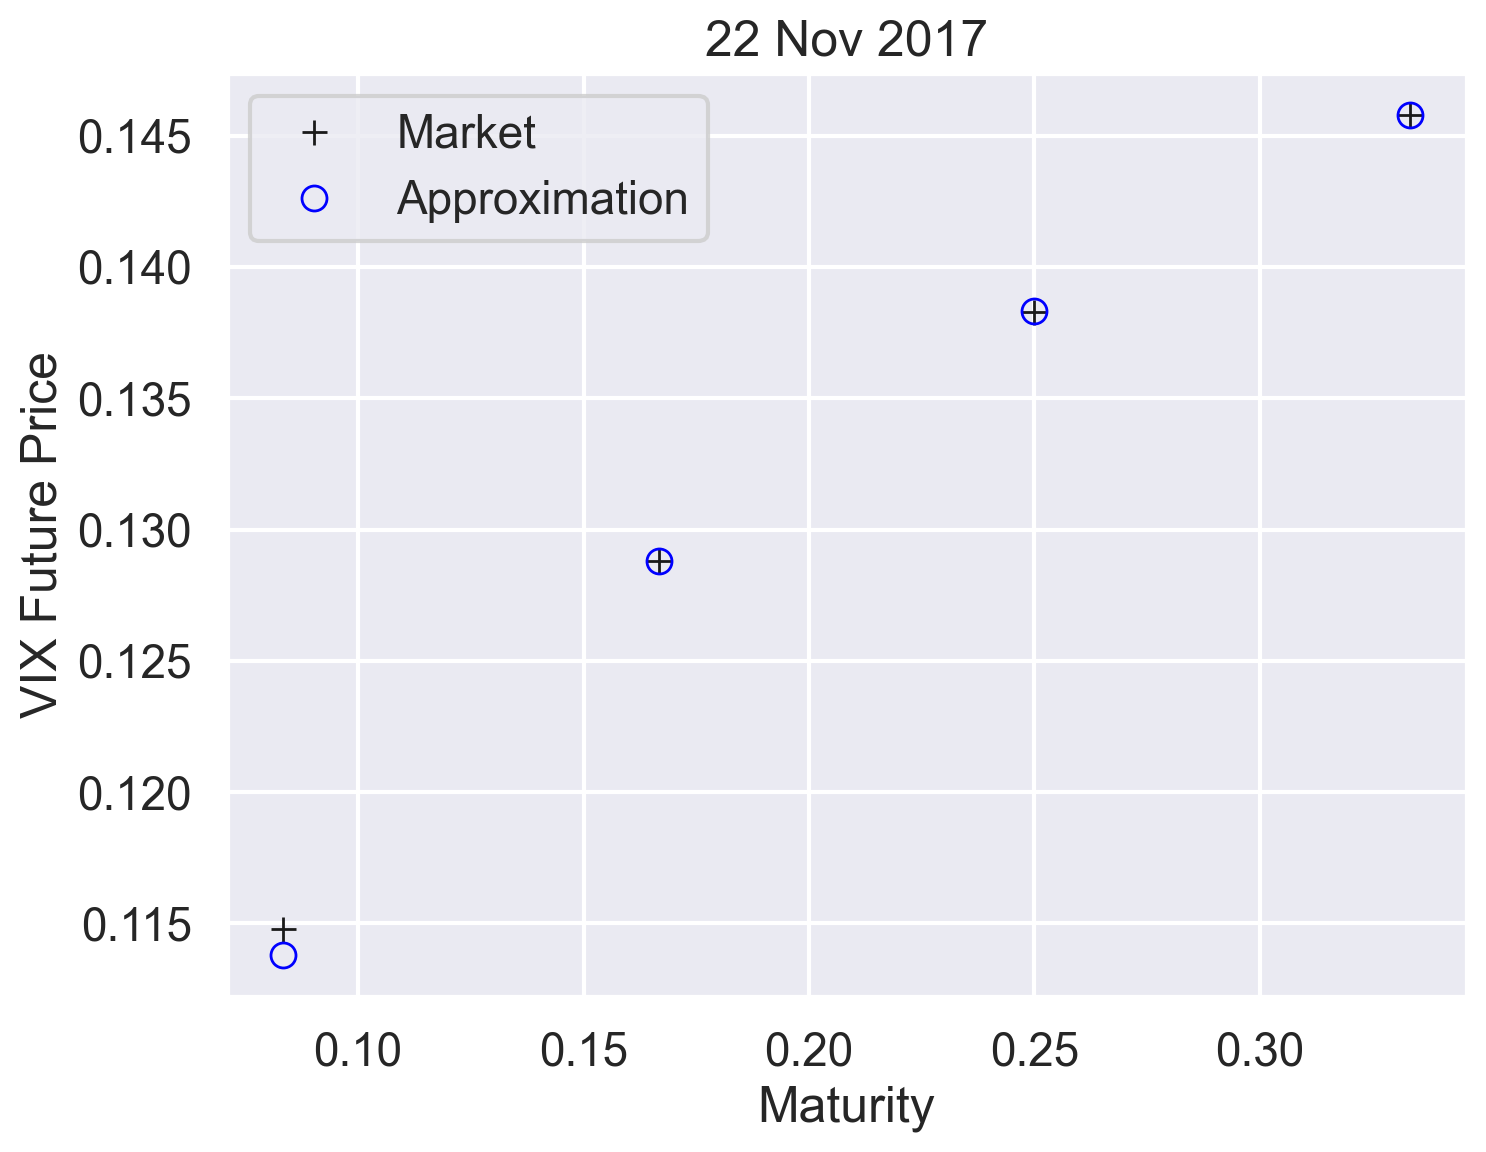

In [132]:
fig, ax = plt.subplots()
ax.plot(
    tab_mat[:4],
    tab_fut[:4],
    "+",
    color="k",
    label="Market",
)
ax.plot(
    tab_mat[:4],
    [fut_approx[T] for T in tab_mat[:4]],
    "o",
    color=COLORS[0],
    fillstyle="none",
    linewidth=1.0,
    label="Approximation",
)
ax.set_xlabel("Maturity")
ax.set_ylabel("VIX Future Price")
ax.set_title("22 Nov 2017")
ax.legend()
plt.show()

## Calibration

In [ ]:
# TODO: redo calibration. assume xi0 piecewise constant.
# be careful with overlaps of maturities.

# 2023-02-15

In [3]:
import calibration
from utils import var_swap_robust, xi_curve_smooth

In [11]:
df_spx = pd.read_csv("data/spx_implied_vol_20230215.csv", index_col=0).dropna()
df_vix = pd.read_csv("data/vix_implied_vol_20230215.csv", index_col=0).dropna()
df_spx["Texp_days"] = (365.25 * df_spx["Texp"]).round().astype(int)
df_vix["Texp_days"] = (365.25 * df_vix["Texp"]).round().astype(int)

df_vix["Mid"] = (df_vix["Ask"] + df_vix["Bid"]) / 2

In [23]:
df_vix["Texp_days"].unique()

array([  7,  14,  20,  28,  35,  63,  91, 126, 154, 182, 217, 245])

In [12]:
# get xi0
res_vs = var_swap_robust(ivol_data=df_spx)
w_in = res_vs["vs_mid"] * res_vs["expiries"]
xi0_smooth = xi_curve_smooth(res_vs["expiries"], w_in, eps=0.03)["xi_curve"]

/Users/florianbourgey/projects/rough-bergomi/utils.py:513: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  wbar_flat = quad(PchipInterpolator(np.sort(y_in), sig_in_y**2), y_min, y_max)[0]


In [13]:
xi0_smooth(0.0)

array(0.01992415)

In [14]:
# Extract unique maturities
mats = df_vix["Texp"].unique()

In [68]:
# Filter the DataFrame for the first maturity
T = mats[1]
df0 = df_vix[df_vix["Texp"] == T]

Ks = 1e-2 * df0["Strike"].to_numpy()
F = 1e-2 * df0["Fwd"].to_numpy()[0]
ks = np.log(Ks / F)
impvols = df0["Mid"].to_numpy()
weights = 1 / (df0["Ask"] - df0["Bid"]).to_numpy()

In [69]:
print(Ks)

[0.17  0.18  0.19  0.2   0.21  0.22  0.23  0.24  0.25  0.26  0.27  0.28
 0.29  0.3   0.31  0.32  0.33  0.34  0.35  0.36  0.37  0.38  0.39  0.4
 0.425 0.45  0.475 0.5   0.55 ]


In [70]:
print(F)

0.2035500629900489


In [71]:
# define optimization parameters

ORDER = 3
EPS = 1e-3
N_QUAD = 50

# xi0, H, eta_1, eta_2, lbd
x0 = np.array([0.04139184, 0.1003548, 6.36398035, 0.3900501, 0.1785362])

In [72]:
optim = calibration.optimize_calibration(
    x0=x0,
    K=Ks,
    F=F,
    impvols=impvols,
    T=T,
    ORDER=ORDER,
    EPS=EPS,
    N_QUAD=N_QUAD,
    weights=weights,
)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.5900e+01                                    1.80e+03    
       1              3         3.4297e+01      4.16e+01       1.56e+00       5.92e+03    
       2              4         2.5911e+01      8.39e+00       1.22e-02       3.08e+04    
       3              7         2.0179e+01      5.73e+00       3.21e-01       4.50e+02    
       4              8         1.7663e+01      2.52e+00       2.63e-02       6.47e+03    
       5             10         1.5348e+01      2.32e+00       2.23e-02       2.32e+02    
       6             20         1.5348e+01      6.71e-06       1.77e-08       6.91e+03    
`xtol` termination condition is satisfied.
Function evaluations 20, initial cost 7.5900e+01, final cost 1.5348e+01, first-order optimality 6.91e+03.


In [77]:
print("Optimized parameters:", optim.x)

Optimized parameters: [0.04139184 0.10339053 5.11819557 0.29056926 0.18926579]


In [73]:
x_optim = optim.x

F_approx, impvols_approx = calibration.fun(
    x_optim,
    K=Ks,
    F=F,
    impvols=impvols,
    T=T,
    ORDER=ORDER,
    EPS=EPS,
    N_QUAD=N_QUAD,
    return_error=False,
)

In [74]:
x_optim

array([0.04139184, 0.10339053, 5.11819557, 0.29056926, 0.18926579])

In [75]:
0.308644 / np.sqrt(2 * 0.1)

np.float64(0.690148964847445)

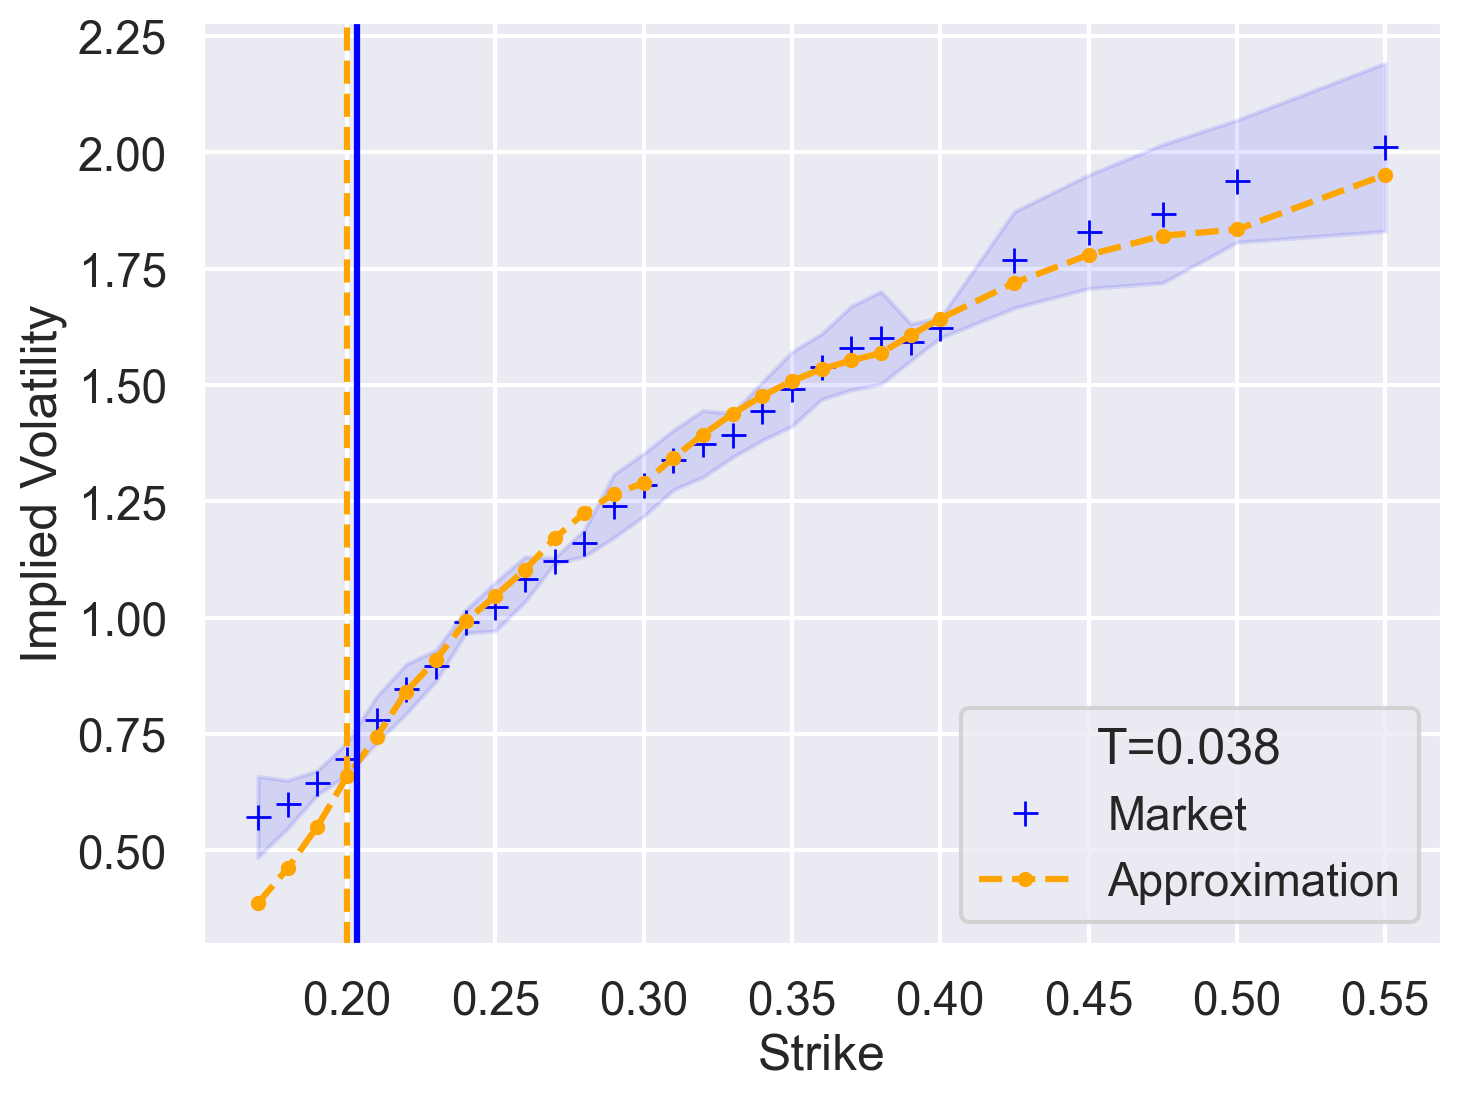

In [76]:
fig, ax = plt.subplots()
ax.plot(Ks, impvols, "+", color="blue", label="Market")
ax.fill_between(Ks, df0["Bid"], df0["Ask"], color="blue", alpha=0.1)
ax.plot(
    Ks,
    impvols_approx,
    ".--",
    color="orange",
    label="Approximation",
)
ax.axvline(F, color="blue", linestyle="-")
ax.axvline(F_approx, color="orange", linestyle="--")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.legend(title=f"T={T:.3f}")
plt.show()

np.float64(-1.3877787807814457e-17)